In [2]:
import polars as pl

In [4]:
df = pl.read_csv("data/raw/pathway/uniprotkb_reviewed_true_2026_03_09.tsv", separator="\t")
df.head()

Entry,Date of creation,Reviewed,Entry Name,Protein names,Gene Names,Organism,Length,Protein existence,DOI ID,PubMed ID,Sequence,EC number,Catalytic activity,PDB,AlphaFoldDB,Active site
str,str,str,str,str,str,str,i64,str,str,str,str,str,str,str,str,str
"""A0A009IHW8""","""2020-02-26""","""reviewed""","""ABTIR_ACIB9""","""2' cyclic ADP-D-ribose synthas…","""J512_3302""","""Acinetobacter baumannii (strai…",269,"""Evidence at protein level""","""10.1016/j.cub.2017.12.024; 10.…","""29395922; 36048923""","""MSLEQKKGADIISKILQIQNSIGKTTSPST…","""3.2.2.-; 3.2.2.6""","""CATALYTIC ACTIVITY: Reaction=N…","""7UWG;7UXU;8G83;""","""A0A009IHW8;""","""ACT_SITE 208; /evidence=""ECO:0…"
"""A0A023I7E1""","""2022-12-14""","""reviewed""","""ENG1_RHIMI""","""Glucan endo-1,3-beta-D-glucosi…","""ENG1 LAM81A""","""Rhizomucor miehei""",796,"""Evidence at protein level""","""10.1107/s090744491301799x; 10.…","""24100321; 34801773""","""MRFQVIVAAATITMITSYIPGVASQSTSDG…","""3.2.1.39""","""CATALYTIC ACTIVITY: Reaction=H…","""4K35;4K3A;5XBZ;5XC2;""","""A0A023I7E1;""","""ACT_SITE 500; /evidence=""ECO:0…"
"""A0A024B7W1""","""2018-01-31""","""reviewed""","""POLG_ZIKVF""","""Genome polyprotein [Cleaved in…",null,"""Zika virus (isolate ZIKV/Human…",3423,"""Evidence at protein level""","""10.1128/genomea.00500-14; 10.1…","""24903869; 26085147; 27524440; …","""MKNPKKKSGGFRIVNMLKRGVARVSPFGGL…","""2.1.1.56; 2.1.1.57; 2.7.7.48; …","""CATALYTIC ACTIVITY: [RNA-direc…","""5GOZ;5GP1;5H30;5H32;5H37;5IRE;…",null,"""ACT_SITE 1553; /note=""Charge r…"
"""A0A024RXP8""","""2017-08-30""","""reviewed""","""GUX1_HYPJR""","""Exoglucanase 1 (EC 3.2.1.91) (…","""cbh1 M419DRAFT_125125""","""Hypocrea jecorina (strain ATCC…",514,"""Evidence at protein level""","""10.1089/ind.2013.0015; 10.1016…","""11270873""","""MYRKLAVISAFLATARAQSACTLQSETHPP…","""3.2.1.91""","""CATALYTIC ACTIVITY: Reaction=H…",null,"""A0A024RXP8;""","""ACT_SITE 229; /note=""Nucleophi…"
"""A0A024SC78""","""2022-05-25""","""reviewed""","""CUTI1_HYPJR""","""Cutinase (EC 3.1.1.74)""","""M419DRAFT_76732""","""Hypocrea jecorina (strain ATCC…",248,"""Evidence at protein level""","""10.1089/ind.2013.0015; 10.1016…","""25219509""","""MRSLAILTTLLAGHAFAYPKPAPQSVNRRD…","""3.1.1.74""","""CATALYTIC ACTIVITY: Reaction=c…","""4PSC;4PSD;4PSE;""","""A0A024SC78;""","""ACT_SITE 164; /note=""Nucleophi…"


In [5]:
for el in df['Catalytic activity'][0].split("CATALYTIC ACTIVITY: "):
    print(el, '\n')

 

Reaction=NAD(+) = 2'cADPR + nicotinamide + H(+); Xref=Rhea:RHEA:75299, ChEBI:CHEBI:15378, ChEBI:CHEBI:17154, ChEBI:CHEBI:57540, ChEBI:CHEBI:194248; Evidence={ECO:0000269|PubMed:36048923}; PhysiologicalDirection=left-to-right; Xref=Rhea:RHEA:75300; Evidence={ECO:0000269|PubMed:36048923};  

Reaction=NAD(+) + H2O = ADP-D-ribose + nicotinamide + H(+); Xref=Rhea:RHEA:16301, ChEBI:CHEBI:15377, ChEBI:CHEBI:15378, ChEBI:CHEBI:17154, ChEBI:CHEBI:57540, ChEBI:CHEBI:57967; EC=3.2.2.6; Evidence={ECO:0000269|PubMed:29395922, ECO:0000269|PubMed:36048923}; PhysiologicalDirection=left-to-right; Xref=Rhea:RHEA:16302; Evidence={ECO:0000269|PubMed:29395922, ECO:0000269|PubMed:36048923};  

Reaction=NADP(+) + H2O = ADP-D-ribose 2'-phosphate + nicotinamide + H(+); Xref=Rhea:RHEA:19849, ChEBI:CHEBI:15377, ChEBI:CHEBI:15378, ChEBI:CHEBI:17154, ChEBI:CHEBI:58349, ChEBI:CHEBI:58673; Evidence={ECO:0000269|PubMed:36048923}; PhysiologicalDirection=left-to-right; Xref=Rhea:RHEA:19850; Evidence={ECO:0000269|Pub

In [6]:
test = df['Catalytic activity'][0]

In [26]:
import re
from itertools import product

def get_pubmed_ids(text: str) -> list[str]:
    return list(set(re.findall(r'PubMed:(\d+)', text)))

def get_rhea_ids(text: str) -> list[str]:
    return list(set(re.findall(r'Rhea:RHEA:(\d+)', text)))

def get_rhea_pubmed(entries: list[str]) -> list[tuple[str, str]]:
    rhea_pubmed = set()
    for elt in entries:
        rids = get_rhea_ids(elt)
        pids = get_pubmed_ids(elt)
        if len(pids) == 0:
            pids = [None]
        rhea_pubmed |= set(product(rids, pids))

    return rhea_pubmed

test_entries = test.split("CATALYTIC ACTIVITY: ")
rp = get_rhea_pubmed(test_entries)
print(rp)

{('16302', '29395922'), ('16302', '36048923'), ('19850', '36048923'), ('19849', '36048923'), ('16301', '29395922'), ('16301', '36048923'), ('75299', '36048923'), ('75300', '36048923')}


In [24]:
set(product([1,2,3], []))

set()

In [25]:
def foo():
    return []

baz = foo() else [None]

SyntaxError: invalid syntax (2717465789.py, line 4)

In [22]:
import requests

def get_pubmed_dates(pubmed_ids: list[str]) -> dict[str, str]:
    if not pubmed_ids:
        return {}

    base_url = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/esummary.fcgi"
    batch_size = 500
    dates: dict[str, str] = {}

    for i in range(0, len(pubmed_ids), batch_size):
        batch = pubmed_ids[i:i + batch_size]
        ids = ",".join(batch)
        url = f"{base_url}?db=pubmed&id={ids}&retmode=json"

        try:
            response = requests.get(url)
            response.raise_for_status()
            result = response.json().get("result", {})
        except requests.exceptions.RequestException as e:
            print(f"An error occurred for batch {i // batch_size + 1}: {e}")
            continue

        dates.update({
            pmid: int(result[pmid]["pubdate"][:4])
            for pmid in batch
            if pmid in result and "error" not in result[pmid]
        })

    return dates


In [23]:
_,  pubmed_ids = zip(*rp)
get_pubmed_dates(pubmed_ids)

{'29395922': 2018, '36048923': 2022}

In [17]:
pubmed_ids

('29395922',
 '36048923',
 '36048923',
 '36048923',
 '29395922',
 '36048923',
 '36048923',
 '36048923')

In [7]:
df = pl.read_parquet("data/processed/pathway/known_reactions.parquet")
df.explode("publication_dates").filter(pl.col("publication_dates").is_not_null()).select(pl.col("publication_dates"))

publication_dates
i32
1986
1988
1990
1992
1993
…
2013
2014
2017


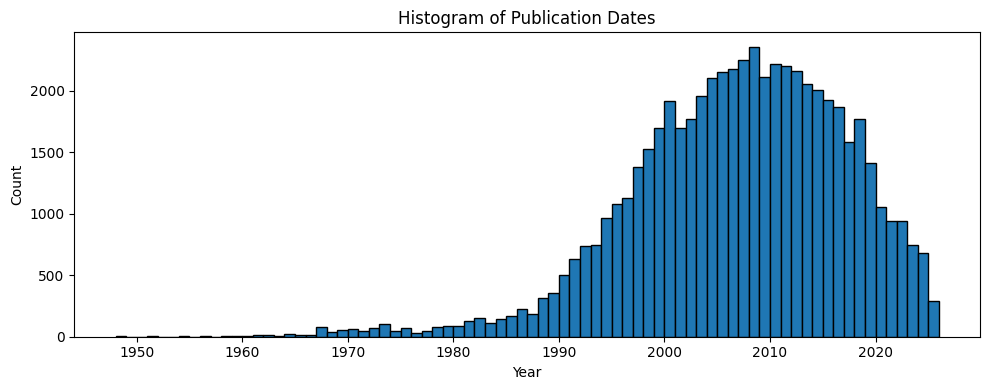

In [8]:
import matplotlib.pyplot as plt

years = (
    df.explode("publication_dates")
      .drop_nulls("publication_dates")
      .get_column("publication_dates")
      .to_list()
)

plt.figure(figsize=(10, 4))
plt.hist(years, bins=range(min(years), max(years) + 2), edgecolor="black")
plt.title("Histogram of Publication Dates")
plt.xlabel("Year")
plt.ylabel("Count")
plt.tight_layout()
plt.show()